# Unsupervised Machine Learning on General-Purpose Data
**Iris Clustering + Customer Segmentation + Dimensionality Reduction**

Two classic non-medical unsupervised tasks:

1. **Clustering** — group Iris flowers by measurements alone (species label hidden during training, used only for validation)
2. **Customer segmentation** — the single most common real-world beginner use case for clustering: grouping customers by income and spending behavior for targeted marketing
3. **Dimensionality reduction (PCA)** — compress and visualize high-dimensional structure



## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
RANDOM_STATE = 42


---
## PART A — Clustering: Iris Species (Unsupervised)

**Task:** group flowers by their 4 measurements alone — the species label is
hidden from the algorithm and used only afterward, to check how well the
discovered clusters line up with the real species.

### A1. Load data (label set aside)

In [ ]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
true_species = pd.Series(data.target, name="true_species")  # NOT used in training

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### A2. Elbow method + silhouette score to choose k

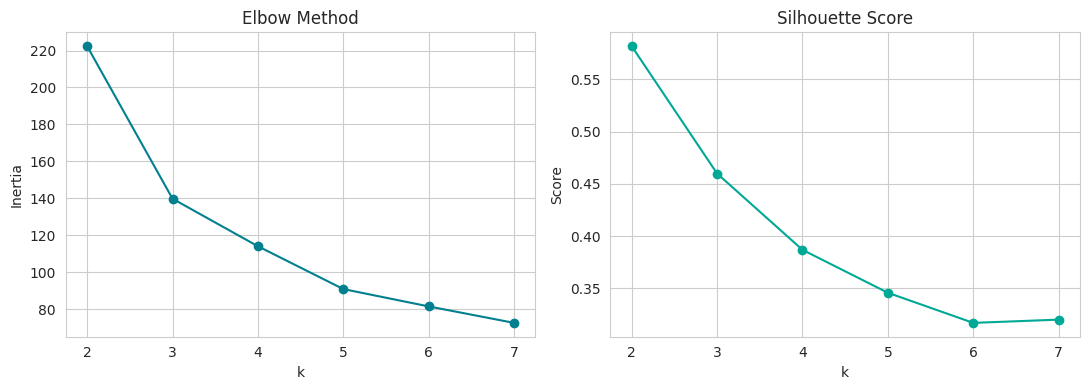

In [ ]:
inertias, sil_scores = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_range, inertias, marker="o", color="#028090")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(k_range, sil_scores, marker="o", color="#00A896")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()


### A3. Fit K-Means at k=3 (we happen to know there are 3 species) and validate

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, cluster_labels)
ari = adjusted_rand_score(true_species, cluster_labels)  # validation only
print(f"Silhouette score: {sil:.3f}")
print(f"Adjusted Rand Index vs. true species (validation only): {ari:.3f}")


Silhouette score: 0.460
Adjusted Rand Index vs. true species (validation only): 0.620


### A4. Visualize clusters vs. true species (using 2 of the 4 features)

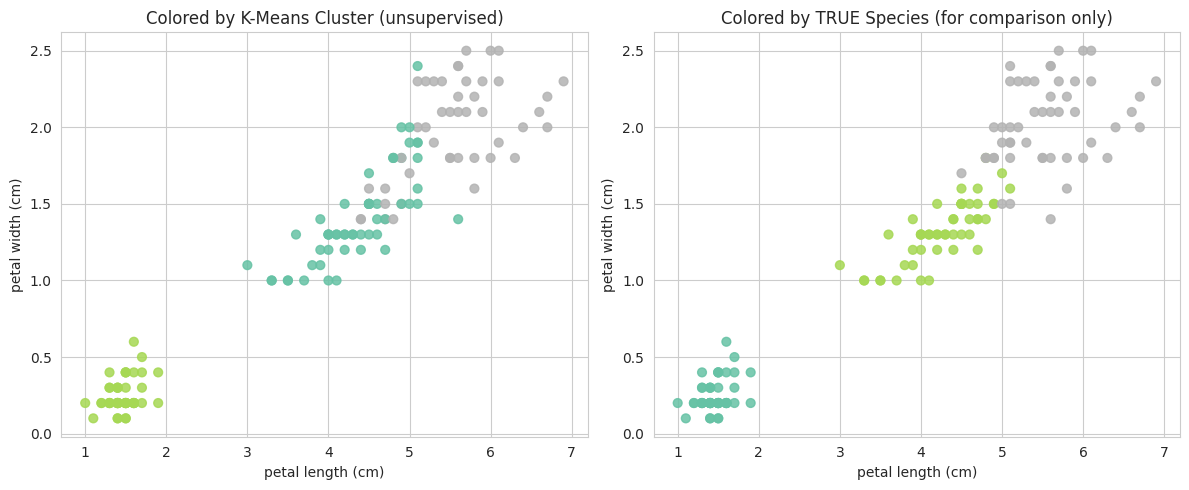

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X.iloc[:, 2], X.iloc[:, 3], c=cluster_labels, cmap="Set2", s=40, alpha=0.85)
axes[0].set_xlabel(X.columns[2]); axes[0].set_ylabel(X.columns[3])
axes[0].set_title("Colored by K-Means Cluster (unsupervised)")

axes[1].scatter(X.iloc[:, 2], X.iloc[:, 3], c=true_species, cmap="Set2", s=40, alpha=0.85)
axes[1].set_xlabel(X.columns[2]); axes[1].set_ylabel(X.columns[3])
axes[1].set_title("Colored by TRUE Species (for comparison only)")

plt.tight_layout()
plt.show()


### A5. Compare K-Means, Hierarchical, and DBSCAN

In [ ]:
algorithms = {
    "K-Means":              KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10),
    "Agglomerative (Ward)": AgglomerativeClustering(n_clusters=3, linkage="ward"),
    "DBSCAN":               DBSCAN(eps=0.5, min_samples=5),
}

comparison = {}
for name, algo in algorithms.items():
    labels = algo.fit_predict(X_scaled)
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    sil = silhouette_score(X_scaled, labels) if n_found > 1 else float("nan")
    ari = adjusted_rand_score(true_species, labels)
    comparison[name] = {"clusters_found": n_found, "silhouette": sil, "ARI_vs_true": ari}

pd.DataFrame(comparison).T.round(3)


,clusters_found,silhouette,ARI_vs_true
K-Means,3.0,0.460,0.620
Agglomerative (Ward),3.0,0.447,0.615
DBSCAN,2.0,0.357,0.442


### A6. Dendrogram

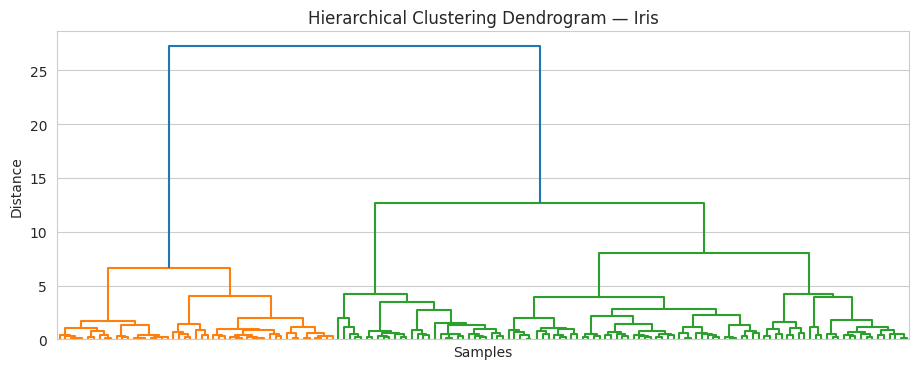

In [ ]:
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(11, 4))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram — Iris")
plt.xlabel("Samples"); plt.ylabel("Distance")
plt.show()


---
## PART B — Customer Segmentation (the classic business use case)

**Task:** a retailer wants to segment customers by **annual income** and
**spending score** to target marketing campaigns — no labels exist because
there's no "correct" segment, just patterns in behavior.

This uses a synthetic-but-realistic dataset (`make_blobs`) so it runs fully
offline. Swap in a real "Mall Customer Segmentation" CSV any time using the
pattern in Section 4.

### B1. Generate & explore

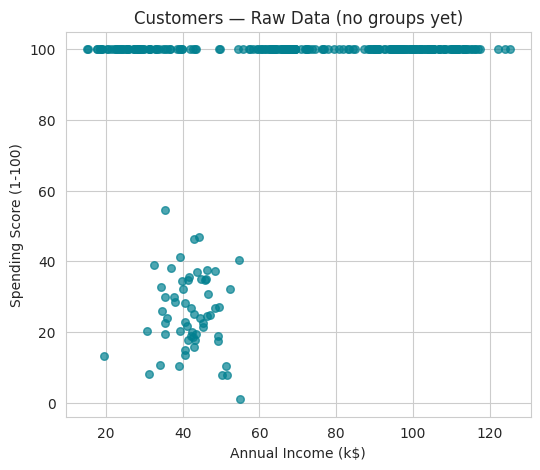

In [ ]:
X_raw, _ = make_blobs(n_samples=300, centers=5, cluster_std=1.1, random_state=RANDOM_STATE)
customers = pd.DataFrame(X_raw, columns=["annual_income_k", "spending_score"])
# Rescale into realistic, human-readable ranges
customers["annual_income_k"] = 15 + (customers["annual_income_k"] - customers["annual_income_k"].min()) * 6
customers["spending_score"] = 1 + (customers["spending_score"] - customers["spending_score"].min()) * 12
customers["spending_score"] = customers["spending_score"].clip(1, 100)

plt.figure(figsize=(6, 5))
plt.scatter(customers["annual_income_k"], customers["spending_score"], s=30, alpha=0.7, color="#028090")
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title("Customers — Raw Data (no groups yet)")
plt.show()


### B2. Elbow method to pick number of segments

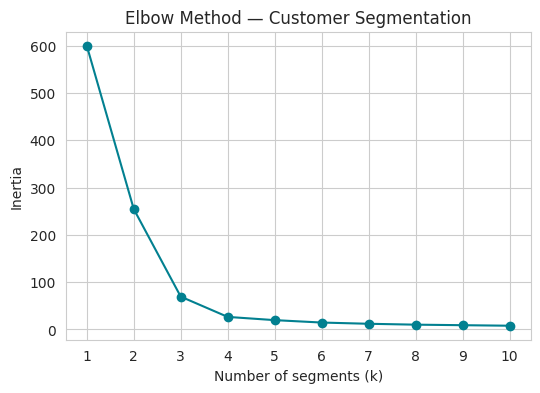

In [ ]:
cust_scaled = StandardScaler().fit_transform(customers)

inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(cust_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), inertias, marker="o", color="#028090")
plt.xlabel("Number of segments (k)"); plt.ylabel("Inertia")
plt.title("Elbow Method — Customer Segmentation")
plt.xticks(range(1, 11))
plt.show()


### B3. Fit K-Means and interpret each segment

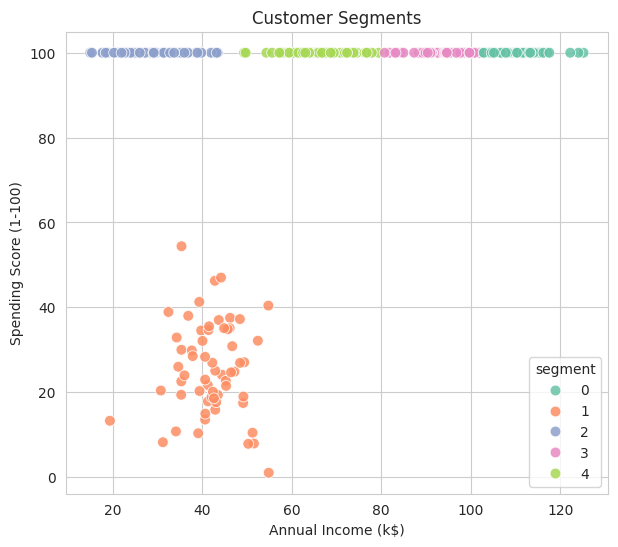

,annual_income_k,spending_score
segment,,
0,110.2,100.0
1,42.0,25.6
2,28.6,100.0
3,94.6,100.0
4,66.0,100.0


In [ ]:
kmeans_cust = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
customers["segment"] = kmeans_cust.fit_predict(cust_scaled)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=customers, x="annual_income_k", y="spending_score",
                 hue="segment", palette="Set2", s=60, alpha=0.85)
plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.show()

# Business-readable summary of each segment
customers.groupby("segment")[["annual_income_k", "spending_score"]].mean().round(1)


**How to read this in practice:** each row above is a marketing persona —
e.g., "high income, low spending" customers might respond to loyalty
incentives, while "low income, high spending" customers might be
price-sensitive but highly engaged. This interpretation step (turning cluster
centers into a business story) is the actual deliverable in a real project,
not just the scatter plot.

---
## PART C — Dimensionality Reduction (PCA) on Iris

Variance captured by 2 components: 95.8%


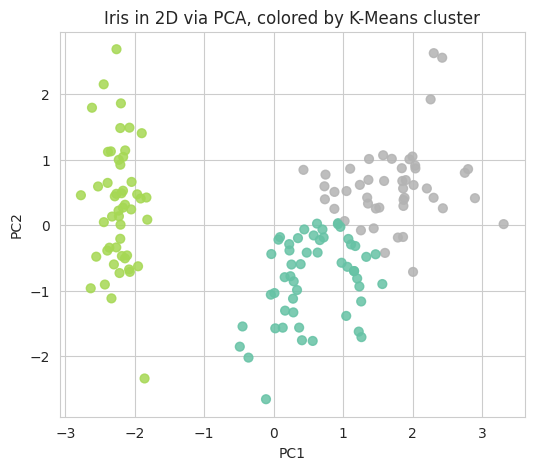

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance captured by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="Set2", s=40, alpha=0.85)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Iris in 2D via PCA, colored by K-Means cluster")
plt.show()
